# Notebook 14 — Análisis multivariante mediante PCA

## Finalidad

En este notebook aplicamos un **Análisis de Componentes Principales (PCA)** para resumir la información de la matriz territorial e identificar sus principales patrones.

Partimos de la matriz estandarizada del Notebook 12, formada por **22 territorios comparables y 21 variables analíticas**.

Los objetivos son:

1. comprobar si la matriz es adecuada para aplicar PCA;
2. decidir cuántos componentes conservar;
3. interpretar las variables y familias que caracterizan cada componente;
4. analizar la posición de los territorios;
5. comparar los resultados con Isolation Forest;
6. preparar las salidas para clustering y Power BI.

## Criterios metodológicos

Utilizamos directamente la matriz preparada en el Notebook 12, sin repetir la selección, las transformaciones ni la estandarización.

Revisamos su adecuación mediante las correlaciones, el índice KMO y la prueba de Bartlett. Si fuera necesario retirar alguna variable específicamente para el PCA, justificaremos la decisión y la mantendremos en la matriz general del proyecto.

Conservamos los **22 territorios**, incluidos los casos singulares detectados en el Notebook 13.

Para seleccionar los componentes combinamos la varianza explicada, el gráfico de sedimentación, el criterio de Kaiser, el análisis paralelo y la interpretación de los resultados.

Los resultados de Isolation Forest se utilizan únicamente como contraste y no se incorporan como variables del PCA.

## Carga y comprobación de la matriz

Cargamos la matriz estandarizada del Notebook 12 y comprobamos que contiene **22 territorios y 21 variables**, sin valores ausentes ni duplicados.

In [1]:
# Importaciones, parámetros y rutas definitivas
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.decomposition import PCA

# Parámetros del análisis.
RANDOM_STATE = 42
N_PARALLEL = 500
LOADING_THRESHOLD = 0.40

# Salidas corregidas del Notebook 12.
DIR_NB12 = Path(
    "/kaggle/input/datasets/aemjeloy/salidas-ntb12"
)
MATRIZ_PATH = (
    DIR_NB12
    / "matriz_estandarizada_22x25.csv"
)
SELECCION_PATH = (
    DIR_NB12
    / "seleccion_final_21_variables.csv"
)

# Salidas corregidas del Notebook 13.
DIR_NB13 = Path(
    "/kaggle/input/datasets/aemjeloy/salidas-ntb-13"
)
ISOLATION_PATH = (
    DIR_NB13
    / "resumen_final_isolation_forest.csv"
)

# Comprobación de las entradas.
archivos_entrada = [
    MATRIZ_PATH,
    SELECCION_PATH,
    ISOLATION_PATH,
]
faltantes = [
    ruta
    for ruta in archivos_entrada
    if not ruta.exists()
]
if faltantes:
    raise FileNotFoundError(
        f"Faltan archivos de entrada: {faltantes}"
    )

# Carpeta de salida del Notebook 14.
OUTPUT_DIR = Path(
    "/kaggle/working/salidas_notebook_14_pca"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
print("Entradas localizadas:", len(archivos_entrada))
print("Matriz NB12:", MATRIZ_PATH)
print("Selección NB12:", SELECCION_PATH)
print("Isolation Forest NB13:", ISOLATION_PATH)
print("Salida NB14:", OUTPUT_DIR)


Entradas localizadas: 3
Matriz NB12: /kaggle/input/datasets/aemjeloy/salidas-ntb12/matriz_estandarizada_22x25.csv
Selección NB12: /kaggle/input/datasets/aemjeloy/salidas-ntb12/seleccion_final_21_variables.csv
Isolation Forest NB13: /kaggle/input/datasets/aemjeloy/salidas-ntb-13/resumen_final_isolation_forest.csv
Salida NB14: /kaggle/working/salidas_notebook_14_pca


In [2]:
# Carga y comprobación
df = pd.read_csv(MATRIZ_PATH)
seleccion = pd.read_csv(SELECCION_PATH)
id_cols = [
    "codigo_geo",
    "nombre_territorio",
    "pais",
    "ambito_modelo",
]
variables = [
    columna for columna in df.columns
    if columna not in id_cols
]
if (
    df.shape != (22, 25)
    or len(variables) != 21
    or set(variables) != set(seleccion["variable"])
    or not df["codigo_geo"].is_unique
    or df[variables].isna().any().any()
    or not np.isfinite(df[variables].to_numpy()).all()
):
    raise ValueError("La matriz necesita revisión.")
print(
    "Matriz:", df.shape,
    "| Variables:", len(variables),
    "| Nulos:", int(df[variables].isna().sum().sum()),
)


Matriz: (22, 25) | Variables: 21 | Nulos: 0


## Correlaciones entre las variables

Revisamos las correlaciones de Pearson y Spearman entre las **21 variables** de la matriz.

Este análisis permite detectar posibles redundancias. Una correlación elevada no implica eliminar automáticamente una variable: también tendremos en cuenta KMO, Bartlett y su significado dentro del proyecto.

In [3]:
# Correlaciones
X = df[variables].copy()

corr_pearson = X.corr()
corr_spearman = X.corr(method="spearman")

pares = []

for i, variable_1 in enumerate(variables):
    for variable_2 in variables[i + 1:]:
        pearson = corr_pearson.loc[
            variable_1,
            variable_2,
        ]
        spearman = corr_spearman.loc[
            variable_1,
            variable_2,
        ]

        pares.append({
            "variable_1": variable_1,
            "variable_2": variable_2,
            "pearson": pearson,
            "spearman": spearman,
            "max_abs": max(
                abs(pearson),
                abs(spearman),
            ),
        })

pares_corr_21 = pd.DataFrame(pares).sort_values(
    "max_abs",
    ascending=False,
).reset_index(drop=True)

print("Parejas:", len(pares_corr_21))
display(pares_corr_21.head(10).round(3))


Parejas: 210


,variable_1,variable_2,pearson,spearman,max_abs
0,electrica_densidad_subestaciones_1000km2,digital_torres_mastiles_1000km2,0.917,0.869,0.917
1,densidad_poblacion,logistica_road_alta_capacidad_km_por_1000km2,0.914,0.787,0.914
2,pvgis_produccion_anual_kwh_kwp,precipitation_daily_mean_mm_2024_2025,-0.831,-0.882,0.882
3,densidad_poblacion,electrica_densidad_alta_tension_km_1000km2,0.821,0.792,0.821
4,pvgis_produccion_anual_kwh_kwp,pvgis_coef_variacion_mensual,-0.684,-0.803,0.803
5,precipitation_daily_mean_mm_2024_2025,hidrica_wei_area_estres_grave_pct_territorio_2...,-0.702,-0.781,0.781
6,logistica_road_alta_capacidad_km_por_1000km2,electrica_densidad_subestaciones_1000km2,0.753,0.731,0.753
7,temperatura_media_2m_c,hidrica_wei_area_estres_grave_pct_territorio_2...,0.748,0.720,0.748
8,logistica_road_alta_capacidad_km_por_1000km2,digital_torres_mastiles_1000km2,0.744,0.691,0.744
9,pvgis_produccion_anual_kwh_kwp,temperatura_media_2m_c,0.738,0.742,0.742


## Adecuación del PCA: KMO y Bartlett

Comprobamos si la matriz es adecuada para aplicar PCA mediante:

- **KMO**, que mide la información común entre las variables.
- **Bartlett**, que comprueba si existen correlaciones suficientes.

Como trabajamos con solo **22 territorios y 21 variables**, interpretaremos los resultados con cautela y junto con las correlaciones anteriores.

In [4]:
# KMO y Bartlett
def calcular_kmo(matriz):
    corr = np.corrcoef(matriz, rowvar=False)
    inversa = np.linalg.pinv(corr)
    parcial = -inversa / np.sqrt(
        np.outer(
            np.diag(inversa),
            np.diag(inversa),
        )
    )
    np.fill_diagonal(corr, 0)
    np.fill_diagonal(parcial, 0)
    r2 = corr ** 2
    p2 = parcial ** 2
    kmo_variables = (
        r2.sum(axis=0)
        / (r2.sum(axis=0) + p2.sum(axis=0))
    )
    kmo_total = (
        r2.sum()
        / (r2.sum() + p2.sum())
    )
    return kmo_total, kmo_variables

def calcular_bartlett(matriz):
    n, p = matriz.shape
    corr = np.corrcoef(matriz, rowvar=False)
    _, log_det = np.linalg.slogdet(corr)
    estadistico = (
        -(n - 1 - (2 * p + 5) / 6)
        * log_det
    )
    gl = p * (p - 1) // 2

    return estadistico, gl, chi2.sf(
        estadistico,
        gl,
    )
kmo_total, kmo_variables = calcular_kmo(X)
bartlett_chi2, bartlett_gl, bartlett_p = (
    calcular_bartlett(X)
)
diagnostico_kmo = pd.DataFrame({
    "variable": variables,
    "kmo_individual": kmo_variables,
}).sort_values("kmo_individual")

print(
    f"KMO: {kmo_total:.3f}",
    f"| Bartlett p: {bartlett_p:.3e}",
)
display(diagnostico_kmo.round(3))


KMO: 0.319 | Bartlett p: 6.644e-31


,variable,kmo_individual
14,digital_data_centers_osm_n,0.154
10,ambiental_densidad_sitios_1000km2,0.166
4,corine_compat_media_0_3,0.204
2,tasa_desempleo,0.208
0,poblacion_edad_laboral,0.214
19,punto_rocio_medio_c,0.251
8,pvgis_perdidas_totales_pct,0.251
16,digital_exchanges_centrales_telecom_1000km2,0.272
3,nivel_formativo_terciario,0.279
18,temperatura_media_2m_c,0.286


## Revisión de la matriz antes del PCA

El KMO global es bajo (`0,319`), aunque Bartlett confirma que existen correlaciones entre las variables.

Comprobamos cuánto cambia el KMO al retirar cada variable por separado. Este análisis es solo orientativo: no eliminaremos ninguna variable automáticamente y también tendremos en cuenta las correlaciones y su significado.

In [5]:
# Impacto de cada variable sobre el KMO
resultados_kmo = []
for variable in variables:
    X_prueba = X.drop(columns=variable)
    kmo_prueba, _ = calcular_kmo(X_prueba)
    resultados_kmo.append({
        "variable_eliminada": variable,
        "kmo_sin_variable": kmo_prueba,
        "cambio_kmo": kmo_prueba - kmo_total,
    })
impacto_kmo = pd.DataFrame(
    resultados_kmo
).sort_values(
    "kmo_sin_variable",
    ascending=False,
).reset_index(drop=True)

print("Variables evaluadas:", len(impacto_kmo))
display(impacto_kmo.round(3))


Variables evaluadas: 21


,variable_eliminada,kmo_sin_variable,cambio_kmo
0,tasa_desempleo,0.434,0.115
1,ambiental_densidad_sitios_1000km2,0.432,0.113
2,temperatura_media_2m_c,0.427,0.108
3,pvgis_perdidas_totales_pct,0.424,0.105
4,electrica_densidad_alta_tension_km_1000km2,0.414,0.095
5,punto_rocio_medio_c,0.411,0.092
6,digital_data_centers_osm_n,0.401,0.082
7,corine_compat_media_0_3,0.378,0.059
8,digital_exchanges_centrales_telecom_1000km2,0.378,0.058
9,nivel_formativo_terciario,0.374,0.054


### Primera reducción de la matriz PCA

Retirar `tasa_desempleo` produce la mayor mejora del KMO, que pasa de `0,319` a `0,434`. Además, esta variable presenta un KMO individual bajo (`0,208`).

Por este motivo, la excluimos provisionalmente de la matriz específica del PCA. La variable se mantiene en la matriz general del proyecto y podrá utilizarse posteriormente en otros análisis.

Después de esta primera retirada volvemos a calcular KMO y Bartlett antes de tomar otra decisión.

In [6]:
# Primera reducción para PCA
variables_pca = [
    variable for variable in variables
    if variable != "tasa_desempleo"
]
X_pca = X[variables_pca].copy()
kmo_pca, kmo_individual_pca = calcular_kmo(
    X_pca
)
bartlett_chi2_pca, bartlett_gl_pca, bartlett_p_pca = (
    calcular_bartlett(X_pca)
)
diagnostico_kmo_pca = pd.DataFrame({
    "variable": variables_pca,
    "kmo_individual": kmo_individual_pca,
}).sort_values("kmo_individual")

print(
    "Variables:", len(variables_pca),
    f"| KMO: {kmo_pca:.3f}",
    f"| Bartlett p: {bartlett_p_pca:.3e}",
)
display(diagnostico_kmo_pca.round(3))


Variables: 20 | KMO: 0.434 | Bartlett p: 3.629e-29


,variable,kmo_individual
0,poblacion_edad_laboral,0.153
13,digital_data_centers_osm_n,0.226
8,pvgis_coef_variacion_mensual,0.293
15,digital_exchanges_centrales_telecom_1000km2,0.372
10,ambiental_penalizacion_media_0_1,0.382
1,densidad_poblacion,0.384
3,corine_compat_media_0_3,0.399
12,electrica_densidad_subestaciones_1000km2,0.409
9,ambiental_densidad_sitios_1000km2,0.432
4,logistica_road_alta_capacidad_km_por_1000km2,0.436


#### Interpretación de la primera reducción

Al retirar `tasa_desempleo`, el KMO mejora de `0,319` a `0,434`, aunque todavía se mantiene por debajo de `0,50`. Bartlett continúa siendo significativo, por lo que existen correlaciones entre las variables.

`poblacion_edad_laboral` presenta ahora el KMO individual más bajo (`0,153`). Antes de retirarla, comprobaremos cuánto mejora realmente el KMO al eliminar cada una de las 20 variables restantes.

Las variables excluidas del PCA se mantienen en la matriz general del proyecto.

### Comprobación de una segunda retirada

Después de retirar `tasa_desempleo`, comprobamos qué ocurriría al eliminar individualmente cada una de las **20 variables restantes**.

El objetivo es comprobar si una segunda retirada mejora claramente el KMO sin perder una dimensión importante del análisis.

In [7]:
# Impacto de una segunda retirada
resultados_kmo_20 = []
for variable in variables_pca:
    X_prueba = X_pca.drop(columns=variable)
    kmo_prueba, _ = calcular_kmo(X_prueba)

    resultados_kmo_20.append({
        "variable_eliminada": variable,
        "kmo_sin_variable": kmo_prueba,
        "cambio_kmo": kmo_prueba - kmo_pca,
    })
impacto_kmo_20 = pd.DataFrame(
    resultados_kmo_20
).sort_values(
    "kmo_sin_variable",
    ascending=False,
).reset_index(drop=True)

print("Variables evaluadas:", len(impacto_kmo_20))
display(impacto_kmo_20.round(3))


Variables evaluadas: 20


,variable_eliminada,kmo_sin_variable,cambio_kmo
0,poblacion_edad_laboral,0.560,0.126
1,pvgis_coef_variacion_mensual,0.537,0.103
2,digital_data_centers_osm_n,0.528,0.094
3,densidad_poblacion,0.527,0.093
4,digital_exchanges_centrales_telecom_1000km2,0.496,0.062
5,logistica_road_alta_capacidad_km_por_1000km2,0.493,0.059
6,electrica_densidad_subestaciones_1000km2,0.481,0.047
7,logistica_places_n_por_1000km2,0.461,0.027
8,hidrica_wei_area_estres_grave_pct_territorio_2...,0.448,0.014
9,corine_compat_media_0_3,0.443,0.009


#### Interpretación de la segunda comprobación

La retirada de `poblacion_edad_laboral` produce la mayor mejora y eleva el KMO de `0,434` a `0,560`.

La variable también presenta el KMO individual más bajo (`0,153`). Por este motivo, la excluiremos únicamente de la matriz específica del PCA, pero seguirá disponible en la matriz general del proyecto.

Con esta segunda retirada alcanzamos un KMO superior a `0,50`. No eliminaremos más variables automáticamente para evitar una pérdida excesiva de información.

### Decisión sobre la matriz PCA

Excluimos `tasa_desempleo` y `poblacion_edad_laboral` únicamente de la matriz específica del PCA.

Con estas dos retiradas, el KMO mejora de `0,319` a `0,560`, superando el nivel orientativo de `0,50`. La matriz del PCA queda formada por **22 territorios y 19 variables**.

Las dos variables se mantienen en la matriz general del proyecto. La familia Socioeconómica continúa representada mediante `densidad_poblacion` y `nivel_formativo_terciario`.

No realizaremos más retiradas automáticas. A partir de esta matriz calcularemos las correlaciones definitivas y ajustaremos el PCA.

In [8]:
# Matriz PCA definitiva
variables_excluidas_pca = [
    "tasa_desempleo",
    "poblacion_edad_laboral",
]
variables_pca = [
    variable for variable in variables
    if variable not in variables_excluidas_pca
]
X_pca = X[variables_pca].copy()
kmo_pca, kmo_individual_pca = calcular_kmo(
    X_pca
)
bartlett_chi2_pca, bartlett_gl_pca, bartlett_p_pca = (
    calcular_bartlett(X_pca)
)
if X_pca.shape != (22, 19):
    raise ValueError(
        "La matriz PCA necesita revisión."
    )
print(
    "Matriz PCA:", X_pca.shape,
    f"| KMO: {kmo_pca:.3f}",
    f"| Bartlett p: {bartlett_p_pca:.3e}",
)


Matriz PCA: (22, 19) | KMO: 0.560 | Bartlett p: 3.514e-27


## Correlaciones de la matriz PCA definitiva

La matriz específica del PCA queda formada por **22 territorios y 19 variables**.

Calculamos nuevamente las correlaciones de Pearson y Spearman para revisar las relaciones que permanecen y guardar las matrices definitivas.

Las correlaciones elevadas se utilizarán como diagnóstico, pero no realizaremos más eliminaciones automáticas.

In [9]:
# Correlaciones de la matriz PCA
corr_pearson_pca = X_pca.corr()
corr_spearman_pca = X_pca.corr(
    method="spearman"
)
corr_pearson_pca.to_csv(
    OUTPUT_DIR / "matriz_correlacion_pearson.csv"
)
corr_spearman_pca.to_csv(
    OUTPUT_DIR / "matriz_correlacion_spearman.csv"
)

pares = []
for i, variable_1 in enumerate(variables_pca):
    for variable_2 in variables_pca[i + 1:]:
        pearson = corr_pearson_pca.loc[
            variable_1,
            variable_2,
        ]
        spearman = corr_spearman_pca.loc[
            variable_1,
            variable_2,
        ]
        pares.append({
            "variable_1": variable_1,
            "variable_2": variable_2,
            "pearson": pearson,
            "spearman": spearman,
            "max_abs": max(
                abs(pearson),
                abs(spearman),
            ),
        })
pares_corr = pd.DataFrame(pares).sort_values(
    "max_abs",
    ascending=False,
).reset_index(drop=True)
pares_corr.to_csv(
    OUTPUT_DIR / "pares_correlacion_ordenados.csv",
    index=False,
)
print(
    "Parejas:", len(pares_corr),
    "| Máxima:", round(
        pares_corr["max_abs"].max(),
        3,
    ),
)
display(pares_corr.head(15).round(3))


Parejas: 171 | Máxima: 0.917


,variable_1,variable_2,pearson,spearman,max_abs
0,electrica_densidad_subestaciones_1000km2,digital_torres_mastiles_1000km2,0.917,0.869,0.917
1,densidad_poblacion,logistica_road_alta_capacidad_km_por_1000km2,0.914,0.787,0.914
2,pvgis_produccion_anual_kwh_kwp,precipitation_daily_mean_mm_2024_2025,-0.831,-0.882,0.882
3,densidad_poblacion,electrica_densidad_alta_tension_km_1000km2,0.821,0.792,0.821
4,pvgis_produccion_anual_kwh_kwp,pvgis_coef_variacion_mensual,-0.684,-0.803,0.803
5,precipitation_daily_mean_mm_2024_2025,hidrica_wei_area_estres_grave_pct_territorio_2...,-0.702,-0.781,0.781
6,logistica_road_alta_capacidad_km_por_1000km2,electrica_densidad_subestaciones_1000km2,0.753,0.731,0.753
7,temperatura_media_2m_c,hidrica_wei_area_estres_grave_pct_territorio_2...,0.748,0.720,0.748
8,logistica_road_alta_capacidad_km_por_1000km2,digital_torres_mastiles_1000km2,0.744,0.691,0.744
9,pvgis_produccion_anual_kwh_kwp,temperatura_media_2m_c,0.738,0.742,0.742


#### Interpretación de las correlaciones finales

La matriz definitiva contiene 171 parejas de variables. La correlación máxima es `0,917`.

Las relaciones más elevadas aparecen entre indicadores territoriales relacionados, pero no corresponden a equivalencias directas. Por este motivo mantenemos las 19 variables y utilizamos el PCA para resumir su información común.

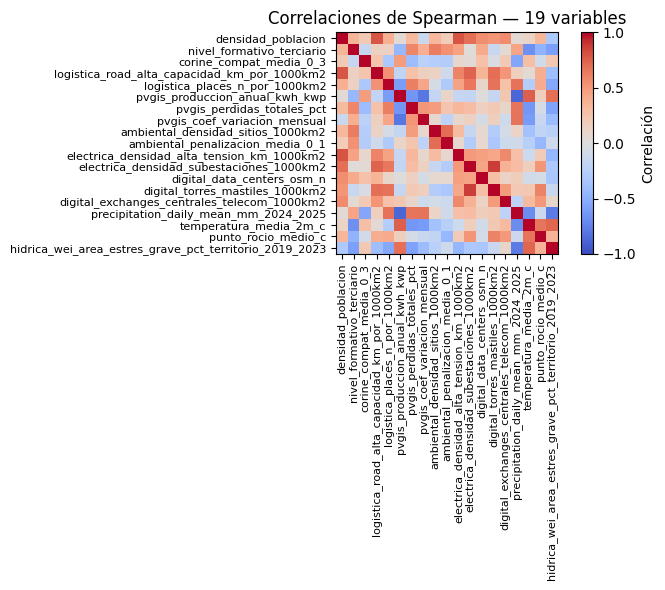

Figura guardada correctamente.


In [10]:
# Mapa de correlaciones de Spearman
fig, ax = plt.subplots(figsize=(8, 6))
imagen = ax.imshow(
    corr_spearman_pca,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

ax.set_xticks(range(len(variables_pca)))
ax.set_yticks(range(len(variables_pca)))
ax.set_xticklabels(
    variables_pca,
    rotation=90,
    fontsize=8,
)
ax.set_yticklabels(
    variables_pca,
    fontsize=8,
)
ax.set_title(
    "Correlaciones de Spearman — 19 variables"
)
fig.colorbar(
    imagen,
    ax=ax,
    label="Correlación",
)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "matriz_correlacion_spearman.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("Figura guardada correctamente.")


## Ajuste del PCA y selección de componentes

Aplicamos el PCA completo sobre la matriz definitiva de **22 territorios y 19 variables**.

Para decidir cuántos componentes conservar, comparamos:

- la varianza explicada y acumulada;
- el criterio de Kaiser, que conserva autovalores superiores a `1`;
- el gráfico de sedimentación;
- el análisis paralelo con `500` matrices aleatorias.

No utilizamos un único criterio. También tendremos en cuenta que los componentes seleccionados sean fáciles de interpretar.

In [11]:
# Ajuste completo del PCA
pca_completo = PCA()
scores_completos = pca_completo.fit_transform(X_pca)
varianza_pct = (
    pca_completo.explained_variance_ratio_ * 100
)
varianza_acumulada_pct = np.cumsum(
    varianza_pct
)

# Autovalores para aplicar el criterio de Kaiser.
autovalores = np.linalg.eigvalsh(
    X_pca.corr()
)[::-1]
resumen_componentes = pd.DataFrame({
    "componente": [
        f"PC{i + 1}"
        for i in range(X_pca.shape[1])
    ],
    "autovalor": autovalores,
    "varianza_explicada_pct": varianza_pct,
    "varianza_acumulada_pct": varianza_acumulada_pct,
    "criterio_kaiser": autovalores > 1,
})
resumen_componentes.to_csv(
    OUTPUT_DIR / "resumen_componentes_completo.csv",
    index=False,
)

print(
    "Componentes:", len(resumen_componentes),
    "| Kaiser:",
    int(resumen_componentes["criterio_kaiser"].sum()),
)
display(resumen_componentes.round(3))


Componentes: 19 | Kaiser: 4


,componente,autovalor,varianza_explicada_pct,varianza_acumulada_pct,criterio_kaiser
0,PC1,6.269,32.994,32.994,True
1,PC2,5.243,27.594,60.588,True
2,PC3,2.650,13.947,74.536,True
3,PC4,1.399,7.363,81.899,True
4,PC5,0.931,4.897,86.796,False
5,PC6,0.574,3.021,89.818,False
6,PC7,0.532,2.800,92.617,False
7,PC8,0.440,2.314,94.932,False
8,PC9,0.322,1.692,96.624,False
9,PC10,0.191,1.007,97.631,False


### Interpretación inicial del PCA

Los cuatro primeros componentes tienen autovalores superiores a `1` y explican conjuntamente el **81,90 %** de la varianza.

Los tres primeros ya recogen el **74,54 %**, mientras que el cuarto añade un **7,36 %**.

Este resultado sugiere conservar entre tres y cuatro componentes, pero todavía debemos compararlo con el análisis paralelo y el gráfico de sedimentación.

### Análisis paralelo

El criterio de Kaiser propone conservar cuatro componentes, que explican conjuntamente el **81,90 %** de la varianza.

Para contrastar este resultado realizamos un análisis paralelo con `500` matrices aleatorias. Conservaremos los componentes cuyos autovalores observados superen el percentil 95 de los autovalores aleatorios.

In [12]:
# Análisis paralelo
rng = np.random.default_rng(RANDOM_STATE)
autovalores_aleatorios = []

for _ in range(N_PARALLEL):
    datos_aleatorios = rng.normal(
        size=X_pca.shape
    )
    correlacion = np.corrcoef(
        datos_aleatorios,
        rowvar=False,
    )
    autovalores_aleatorios.append(
        np.linalg.eigvalsh(correlacion)[::-1]
    )
autovalores_aleatorios = np.array(
    autovalores_aleatorios
)
media_aleatoria = autovalores_aleatorios.mean(axis=0)
percentil_95 = np.percentile(
    autovalores_aleatorios,
    95,
    axis=0,
)
analisis_paralelo = pd.DataFrame({
    "componente": resumen_componentes["componente"],
    "autovalor_observado": autovalores,
    "autovalor_aleatorio_medio": media_aleatoria,
    "autovalor_aleatorio_p95": percentil_95,
})
analisis_paralelo["retener"] = (
    autovalores > percentil_95
)
n_kaiser = int((autovalores > 1).sum())
n_paralelo = int(
    analisis_paralelo["retener"].sum()
)
n_varianza_70 = int(
    np.argmax(varianza_acumulada_pct >= 70) + 1
)
n_varianza_80 = int(
    np.argmax(varianza_acumulada_pct >= 80) + 1
)
analisis_paralelo.to_csv(
    OUTPUT_DIR / "analisis_paralelo.csv",
    index=False,
)

print(
    "Kaiser:", n_kaiser,
    "| Paralelo:", n_paralelo,
    "| ≥70 %:", n_varianza_70,
    "| ≥80 %:", n_varianza_80,
)
display(analisis_paralelo.round(3))


Kaiser: 4 | Paralelo: 3 | ≥70 %: 3 | ≥80 %: 4


,componente,autovalor_observado,autovalor_aleatorio_medio,autovalor_aleatorio_p95,retener
0,PC1,6.269,3.142,3.587,True
1,PC2,5.243,2.611,2.913,True
2,PC3,2.650,2.247,2.503,True
3,PC4,1.399,1.941,2.144,False
4,PC5,0.931,1.670,1.870,False
5,PC6,0.574,1.436,1.604,False
6,PC7,0.532,1.224,1.386,False
7,PC8,0.440,1.040,1.188,False
8,PC9,0.322,0.875,1.017,False
9,PC10,0.191,0.718,0.857,False


#### Interpretación del análisis paralelo

El análisis paralelo propone conservar **tres componentes**, ya que solo PC1, PC2 y PC3 superan el percentil 95 de los autovalores aleatorios.

Estos tres componentes explican conjuntamente el **74,54 %** de la varianza. El criterio de Kaiser propone cuatro, pero PC4 no supera la referencia aleatoria.

Por ahora, la solución de tres componentes parece la más adecuada. La contrastaremos con el gráfico de sedimentación antes de tomar la decisión final.

### Gráfico de sedimentación

Representamos los autovalores observados, el percentil 95 del análisis paralelo y el límite `1` del criterio de Kaiser.

El gráfico nos ayudará a comparar los criterios y decidir cuántos componentes conservar.

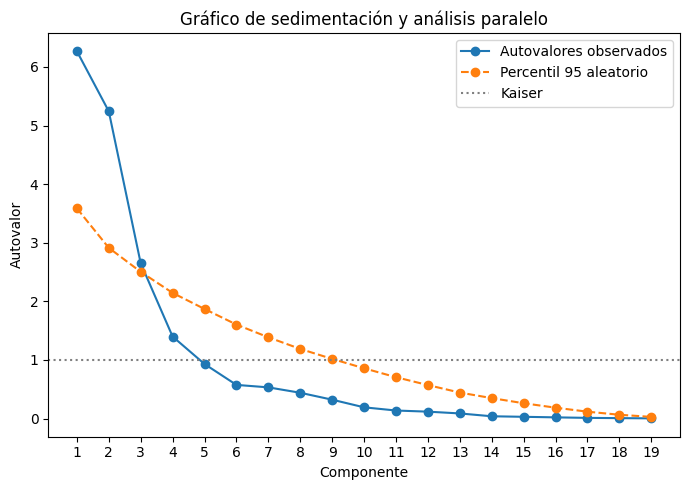

In [13]:
# Gráfico de sedimentación
componentes = np.arange(1, len(autovalores) + 1)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    componentes,
    autovalores,
    marker="o",
    label="Autovalores observados",
)
ax.plot(
    componentes,
    percentil_95,
    marker="o",
    linestyle="--",
    label="Percentil 95 aleatorio",
)
ax.axhline(
    1,
    linestyle=":",
    color="gray",
    label="Kaiser",
)
ax.set(
    xlabel="Componente",
    ylabel="Autovalor",
    title="Gráfico de sedimentación y análisis paralelo",
)
ax.set_xticks(componentes)
ax.legend()

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "scree_plot_analisis_paralelo.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)



#### Interpretación del gráfico

El gráfico respalda una solución de **tres componentes**. Los tres primeros autovalores superan la referencia del análisis paralelo y explican conjuntamente el **74,54 %** de la varianza.

Aunque PC4 cumple el criterio de Kaiser, no supera el valor aleatorio y aporta solo un **7,36 %** adicional. Por tanto, la solución de tres componentes parece más parsimoniosa.

### Varianza explicada

Representamos la varianza explicada por cada componente y su valor acumulado.

Los niveles del **70 %** y del **80 %** se utilizan como referencias, pero no como criterios obligatorios para seleccionar los componentes.

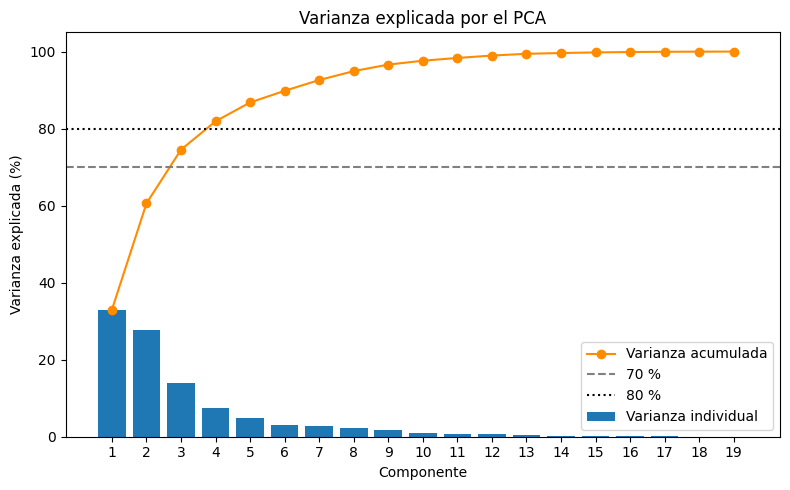

In [14]:
# Varianza explicada
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    componentes,
    varianza_pct,
    label="Varianza individual",
)
ax.plot(
    componentes,
    varianza_acumulada_pct,
    marker="o",
    color="darkorange",
    label="Varianza acumulada",
)
ax.axhline(
    70,
    linestyle="--",
    color="gray",
    label="70 %",
)
ax.axhline(
    80,
    linestyle=":",
    color="black",
    label="80 %",
)
ax.set(
    xlabel="Componente",
    ylabel="Varianza explicada (%)",
    title="Varianza explicada por el PCA",
)
ax.set_xticks(componentes)
ax.legend()

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "varianza_explicada_pca.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)



#### Interpretación de la varianza explicada

Los tres primeros componentes explican el **74,54 %** de la varianza. Al añadir PC4 se alcanza el **81,90 %**, aunque su aportación individual es bastante menor.

La varianza acumulada crece rápidamente con los primeros componentes y después se estabiliza, ya que los componentes sucesivos aportan cada vez menos información adicional.

### Selección final de componentes

Los criterios ofrecen resultados diferentes. Kaiser propone **cuatro componentes**, mientras que el análisis paralelo recomienda **tres**.

Los tres primeros componentes explican el **74,54 %** de la varianza y superan la referencia aleatoria. PC4 eleva la varianza acumulada al **81,90 %**, pero no supera el percentil 95 del análisis paralelo.

El gráfico de sedimentación también muestra un cambio claro después de PC3. Por estos motivos, conservamos **tres componentes principales** como solución definitiva.

In [15]:
# PCA definitivo
N_COMPONENTES = 3
pca_final = PCA(n_components=N_COMPONENTES)
scores_pca = pca_final.fit_transform(X_pca)
nombres_pc = [
    f"PC{i + 1}"
    for i in range(N_COMPONENTES)
]
varianza_final_pct = (
    pca_final.explained_variance_ratio_ * 100
)
resumen_pca_final = pd.DataFrame({
    "componente": nombres_pc,
    "varianza_explicada_pct": varianza_final_pct,
    "varianza_acumulada_pct": np.cumsum(
        varianza_final_pct
    ),
})
resumen_pca_final.to_csv(
    OUTPUT_DIR / "resumen_pca_final.csv",
    index=False,
)

print(
    "Matriz reducida:", scores_pca.shape,
    "| Varianza acumulada:",
    f"{varianza_final_pct.sum():.2f} %",
)
display(resumen_pca_final.round(3))


Matriz reducida: (22, 3) | Varianza acumulada: 74.54 %


,componente,varianza_explicada_pct,varianza_acumulada_pct
0,PC1,32.994,32.994
1,PC2,27.594,60.588
2,PC3,13.947,74.536


#### Resultado de la selección

La solución definitiva conserva **tres componentes**, que resumen el **74,54 %** de la varianza de las 19 variables utilizadas en el PCA.

La nueva matriz contiene 22 territorios y 3 componentes. A continuación analizamos las cargas para interpretar qué representa cada componente.

### Cargas, contribuciones y comunalidades

Analizamos las variables que caracterizan los tres componentes mediante:

- las **cargas**, que muestran la dirección e intensidad de cada relación;
- las **contribuciones**, que indican el peso de cada variable en el componente;
- las **comunalidades**, que muestran qué parte de cada variable queda representada por los tres componentes.

También incorporamos la familia temática de cada variable. Prestaremos especial atención a las cargas con un valor absoluto igual o superior a `0,40`.

In [16]:
# Cargas, contribuciones
scores_df = pd.DataFrame(
    scores_pca,
    columns=nombres_pc,
    index=X_pca.index,
)

# Correlación entre cada variable y componente.
loadings = pd.DataFrame({
    pc: X_pca.corrwith(scores_df[pc])
    for pc in nombres_pc
})
loadings.index.name = "variable"

familias_variables = seleccion[
    ["variable", "familia"]
]
loadings_export = (
    loadings
    .reset_index()
    .merge(
        familias_variables,
        on="variable",
        how="left",
    )
)

# Información de cada variable recogida por los tres componentes.
tabla_comunalidades = (
    loadings
    .pow(2)
    .sum(axis=1)
    .rename("comunalidad")
    .reset_index()
    .merge(
        familias_variables,
        on="variable",
        how="left",
    )
    .sort_values(
        "comunalidad",
        ascending=False,
    )
)

# Peso porcentual de cada variable en cada componente.
contribuciones = pd.DataFrame(
    pca_final.components_.T ** 2 * 100,
    index=variables_pca,
    columns=nombres_pc,
)
contribuciones.index.name = "variable"
loadings_export.to_csv(
    OUTPUT_DIR / "cargas_pca.csv",
    index=False,
)
contribuciones.reset_index().to_csv(
    OUTPUT_DIR / "contribuciones_variables_componentes.csv",
    index=False,
)
tabla_comunalidades.to_csv(
    OUTPUT_DIR / "comunalidades_variables.csv",
    index=False,
)
if not tabla_comunalidades["comunalidad"].between(
    0, 1
).all():
    raise ValueError("Las comunalidades necesitan revisión.")

print(
    "Variables:", len(loadings),
    "| Componentes:", len(nombres_pc),
)
display(loadings_export.round(3))
display(tabla_comunalidades.round(3))


Variables: 19 | Componentes: 3


,variable,PC1,PC2,PC3,familia
0,densidad_poblacion,0.728,0.430,0.479,Socioeconómica
1,nivel_formativo_terciario,0.478,-0.581,0.571,Socioeconómica
2,corine_compat_media_0_3,-0.035,0.587,0.355,CORINE
3,logistica_road_alta_capacidad_km_por_1000km2,0.801,0.426,0.252,Logística
4,logistica_places_n_por_1000km2,0.802,0.010,-0.433,Logística
5,pvgis_produccion_anual_kwh_kwp,-0.581,0.664,0.274,PVGIS
6,pvgis_perdidas_totales_pct,0.719,-0.348,-0.085,PVGIS
7,pvgis_coef_variacion_mensual,0.524,-0.432,-0.374,PVGIS
8,ambiental_densidad_sitios_1000km2,0.273,-0.483,0.543,Ambiental
9,ambiental_penalizacion_media_0_1,-0.153,-0.486,0.707,Ambiental


,variable,comunalidad,familia
0,densidad_poblacion,0.945,Socioeconómica
15,precipitation_daily_mean_mm_2024_2025,0.894,Climática
1,nivel_formativo_terciario,0.892,Socioeconómica
3,logistica_road_alta_capacidad_km_por_1000km2,0.888,Logística
13,digital_torres_mastiles_1000km2,0.884,Digital
16,temperatura_media_2m_c,0.879,Climática
11,electrica_densidad_subestaciones_1000km2,0.861,Eléctrica
5,pvgis_produccion_anual_kwh_kwp,0.854,PVGIS
4,logistica_places_n_por_1000km2,0.831,Logística
10,electrica_densidad_alta_tension_km_1000km2,0.763,Eléctrica


### Interpretación inicial

Las cargas muestran que los componentes combinan variables de diferentes familias. Una carga positiva o negativa indica la dirección de la relación, pero no significa que el resultado sea bueno o malo.

Los tres componentes representan adecuadamente 17 de las 19 variables, con comunalidades iguales o superiores a `0,60`.

`corine_compat_media_0_3` presenta una representación moderada (`0,471`) y `digital_data_centers_osm_n` una representación más baja (`0,318`). Las mantenemos en el análisis, pero interpretaremos sus resultados con mayor cautela.

No eliminamos más variables, ya que la matriz PCA quedó cerrada en el apartado anterior.

In [17]:
# Variables principales por componente
familias = seleccion.set_index(
    "variable"
)["familia"]

registros_top = []
for pc in nombres_pc:
    variables_top = (
        loadings[pc]
        .abs()
        .nlargest(8)
        .index
    )
    for posicion, variable in enumerate(
        variables_top,
        start=1,
    ):
        carga = loadings.loc[variable, pc]
        registros_top.append({
            "componente": pc,
            "posicion": posicion,
            "variable": variable,
            "familia": familias[variable],
            "carga": carga,
            "carga_abs": abs(carga),
            "supera_umbral_040": (
                abs(carga) >= LOADING_THRESHOLD
            ),
        })
top_variables = pd.DataFrame(registros_top)
top_variables.to_csv(
    OUTPUT_DIR / "variables_principales_por_componente.csv",
    index=False,
)
print(
    "Componentes:", len(nombres_pc),
    "| Registros:", len(top_variables),
)
display(top_variables.round(3))


Componentes: 3 | Registros: 24


,componente,posicion,variable,familia,carga,carga_abs,supera_umbral_040
0,PC1,1,logistica_places_n_por_1000km2,Logística,0.802,0.802,True
1,PC1,2,logistica_road_alta_capacidad_km_por_1000km2,Logística,0.801,0.801,True
2,PC1,3,densidad_poblacion,Socioeconómica,0.728,0.728,True
3,PC1,4,electrica_densidad_alta_tension_km_1000km2,Eléctrica,0.727,0.727,True
4,PC1,5,pvgis_perdidas_totales_pct,PVGIS,0.719,0.719,True
5,PC1,6,digital_torres_mastiles_1000km2,Digital,0.680,0.680,True
6,PC1,7,electrica_densidad_subestaciones_1000km2,Eléctrica,0.678,0.678,True
7,PC1,8,hidrica_wei_area_estres_grave_pct_territorio_2...,Hídrica,-0.653,0.653,True
8,PC2,1,temperatura_media_2m_c,Climática,0.843,0.843,True
9,PC2,2,punto_rocio_medio_c,Climática,0.705,0.705,True


### Lectura inicial de las variables principales

PC1 está relacionado con los indicadores logísticos, demográficos, eléctricos y digitales, junto con las pérdidas PVGIS, y en sentido contrario al estrés hídrico grave.

PC2 combina condiciones climáticas y fotovoltaicas con infraestructura digital y eléctrica. El nivel formativo terciario aparece en sentido contrario dentro de este eje.

PC3 está caracterizado por variables ambientales y socioeconómicas, frente a la precipitación y la densidad de núcleos poblados.

Estas interpretaciones son provisionales. Las completaremos mediante las contribuciones por familias y la posición de los territorios.

## Interpretación por familias

Agrupamos las contribuciones de las variables por familia para comprobar qué dimensiones tienen más peso en cada componente.

Estos resultados complementan las cargas individuales. Debemos interpretarlos con cautela, ya que las familias con más variables pueden acumular una contribución mayor.

In [18]:
# Contribución por familias
contrib_familias = (
    contribuciones
    .reset_index()
    .merge(
        familias_variables,
        on="variable",
        how="left",
    )
    .groupby(
        "familia",
        as_index=False,
    )[nombres_pc]
    .sum()
)

if not np.allclose(
    contrib_familias[nombres_pc].sum(),
    100,
):
    raise ValueError(
        "Las contribuciones necesitan revisión."
    )
contrib_familias.to_csv(
    OUTPUT_DIR / "contribucion_familias_componentes.csv",
    index=False,
)
print("Familias:", len(contrib_familias))
display(contrib_familias.round(2))


Familias: 9


,familia,PC1,PC2,PC3
0,Ambiental,1.57,8.95,29.99
1,CORINE,0.02,6.56,4.75
2,Climática,10.88,28.33,10.36
3,Digital,14.33,15.15,8.34
4,Eléctrica,15.77,8.25,7.66
5,Hídrica,6.80,5.05,0.11
6,Logística,20.50,3.47,9.47
7,PVGIS,18.02,14.26,8.40
8,Socioeconómica,12.11,9.98,20.93


### Interpretación de las contribuciones por familias

PC1 está caracterizado por las familias Logística (`20,50 %`), PVGIS (`18,02 %`), Eléctrica (`15,77 %`) y Digital (`14,33 %`). Representa un eje mixto relacionado con las infraestructuras territoriales, la logística y las condiciones fotovoltaicas.

PC2 está dominado por la familia Climática (`28,33 %`), seguida de Digital (`15,15 %`) y PVGIS (`14,26 %`). Refleja una dimensión climática, solar y tecnológica.

PC3 está explicado sobre todo por Ambiental (`29,99 %`) y Socioeconómica (`20,93 %`). Representa una dimensión ambiental y social.

Las contribuciones muestran el peso de cada familia, pero no su dirección. Para distinguir relaciones positivas y negativas debemos consultar también las cargas.

### Contribuciones por familia

Representamos el peso de cada familia en PC1, PC2 y PC3 para facilitar su comparación.

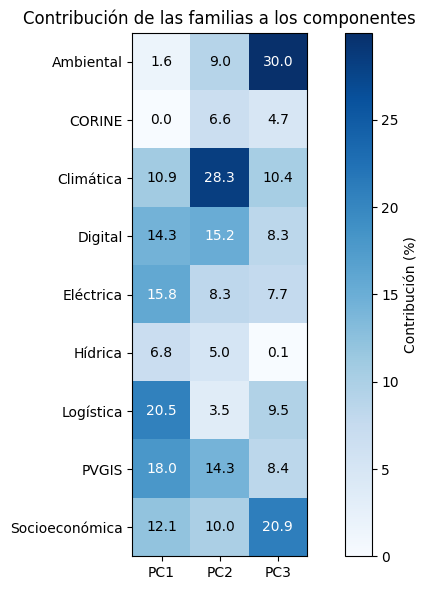

In [19]:
# Mapa de contribución por familias
mapa_familias = contrib_familias.set_index(
    "familia"
)[nombres_pc]
fig, ax = plt.subplots(figsize=(8, 6))
imagen = ax.imshow(
    mapa_familias,
    cmap="Blues",
    vmin=0,
)
ax.set_xticks(range(len(nombres_pc)))
ax.set_xticklabels(nombres_pc)
ax.set_yticks(range(len(mapa_familias)))
ax.set_yticklabels(mapa_familias.index)
limite_color = mapa_familias.to_numpy().max() / 2

for fila in range(mapa_familias.shape[0]):
    for columna in range(mapa_familias.shape[1]):
        valor = mapa_familias.iloc[fila, columna]
        ax.text(
            columna,
            fila,
            f"{valor:.1f}",
            ha="center",
            va="center",
            color=(
                "white"
                if valor > limite_color
                else "black"
            ),
        )
ax.set_title(
    "Contribución de las familias a los componentes"
)
fig.colorbar(
    imagen,
    ax=ax,
    label="Contribución (%)",
)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "contribucion_familias_componentes.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)



## Puntuaciones territoriales

Asignamos a cada territorio sus puntuaciones en PC1, PC2 y PC3.

Estas puntuaciones muestran su posición relativa en cada componente. Guardamos la matriz para utilizarla posteriormente en el clustering y compararla con los resultados de Isolation Forest.

In [20]:
# Puntuaciones territoriales
scores_territorios = df[
    [
        "codigo_geo",
        "nombre_territorio",
        "pais",
    ]
].copy()

scores_territorios[nombres_pc] = scores_pca
if (
    scores_territorios.shape != (22, 6)
    or not scores_territorios["codigo_geo"].is_unique
    or scores_territorios[nombres_pc].isna().any().any()
):
    raise ValueError(
        "Las puntuaciones territoriales necesitan revisión."
    )
scores_territorios.to_csv(
    OUTPUT_DIR / "puntuaciones_territoriales_pca.csv",
    index=False,
)

print(
    "Territorios:", len(scores_territorios),
    "| Componentes:", len(nombres_pc),
)
display(scores_territorios.round(3))


Territorios: 22 | Componentes: 3


,codigo_geo,nombre_territorio,pais,PC1,PC2,PC3
0,ES11,Galicia,España,2.659,-1.963,-2.274
1,ES12,Principado de Asturias,España,2.050,-3.168,-0.548
2,ES13,Cantabria,España,2.523,-3.212,0.001
3,ES21,País Vasco,España,3.439,-2.545,1.386
4,ES22,Comunidad Foral de Navarra,España,0.212,-3.000,0.103
5,ES23,La Rioja,España,-0.645,-2.390,-0.465
6,ES24,Aragón,España,-1.971,-1.653,0.850
7,ES30,Comunidad de Madrid,España,1.285,0.875,3.512
8,ES41,Castilla y León,España,-1.472,-1.687,0.017
9,ES42,Castilla-La Mancha,España,-3.623,-0.486,-0.562


### Lectura inicial de las puntuaciones

Grande Lisboa y Península de Setúbal presentan valores elevados en PC1 y PC2. Comunidad de Madrid destaca principalmente en PC3.

Extremadura, Alentejo y Castilla-La Mancha aparecen en el extremo negativo de PC1. Cantabria, Asturias y Navarra se sitúan en el extremo negativo de PC2, mientras que Oeste e Vale do Tejo y Centro (PT) destacan en el extremo negativo de PC3.

Estas posiciones no representan un ranking de idoneidad. Indican únicamente perfiles territoriales diferentes dentro del espacio definido por el PCA.

In [21]:
# Territorios extremos por componente
tablas_extremos = []
for pc in nombres_pc:
    positivos = scores_territorios.nlargest(
        3, pc
    ).copy()
    positivos["extremo"] = "positivo"
    negativos = scores_territorios.nsmallest(
        3, pc
    ).copy()
    negativos["extremo"] = "negativo"
    tabla_pc = pd.concat(
        [positivos, negativos]
    )
    tabla_pc["componente"] = pc
    tabla_pc["puntuacion"] = tabla_pc[pc]
    tablas_extremos.append(
        tabla_pc[
            [
                "componente",
                "extremo",
                "codigo_geo",
                "nombre_territorio",
                "pais",
                "puntuacion",
            ]
        ]
    )
extremos_df = pd.concat(
    tablas_extremos,
    ignore_index=True,
)
extremos_df.to_csv(
    OUTPUT_DIR / "territorios_extremos_por_componente.csv",
    index=False,
)

print("Registros extremos:", len(extremos_df))
display(extremos_df.round(3))


Registros extremos: 18


,componente,extremo,codigo_geo,nombre_territorio,pais,puntuacion
0,PC1,positivo,PT1A,Grande Lisboa,Portugal,4.518
1,PC1,positivo,ES21,País Vasco,España,3.439
2,PC1,positivo,PT1B,Península de Setúbal,Portugal,2.823
3,PC1,negativo,ES43,Extremadura,España,-4.286
4,PC1,negativo,PT1C,Alentejo,Portugal,-3.635
5,PC1,negativo,ES42,Castilla-La Mancha,España,-3.623
6,PC2,positivo,PT1A,Grande Lisboa,Portugal,4.695
7,PC2,positivo,PT1B,Península de Setúbal,Portugal,4.001
8,PC2,positivo,PT15,Algarve,Portugal,2.853
9,PC2,negativo,ES13,Cantabria,España,-3.212


### Interpretación de los territorios extremos

Grande Lisboa y Península de Setúbal destacan en los extremos positivos de PC1 y PC2. Comunidad de Madrid ocupa el extremo positivo de PC3.

Algarve también presenta una posición elevada en PC2. Estos resultados son coherentes con algunas de las singularidades observadas mediante Isolation Forest.

Estar en un extremo del PCA no significa automáticamente ser anómalo ni más idóneo. Solo indica una posición territorial diferenciada dentro de ese componente.

## Plano factorial y biplot

Representamos los territorios en el plano PC1–PC2, que explica el **60,59 %** de la varianza.

El gráfico permite observar la proximidad entre territorios, los casos extremos y la dirección de las variables más relacionadas con ambos componentes.

Mostramos solo las variables principales para evitar sobrecargar la figura. PC3 no aparece en este plano, pero se mantiene en la solución definitiva y en la matriz destinada al clustering.

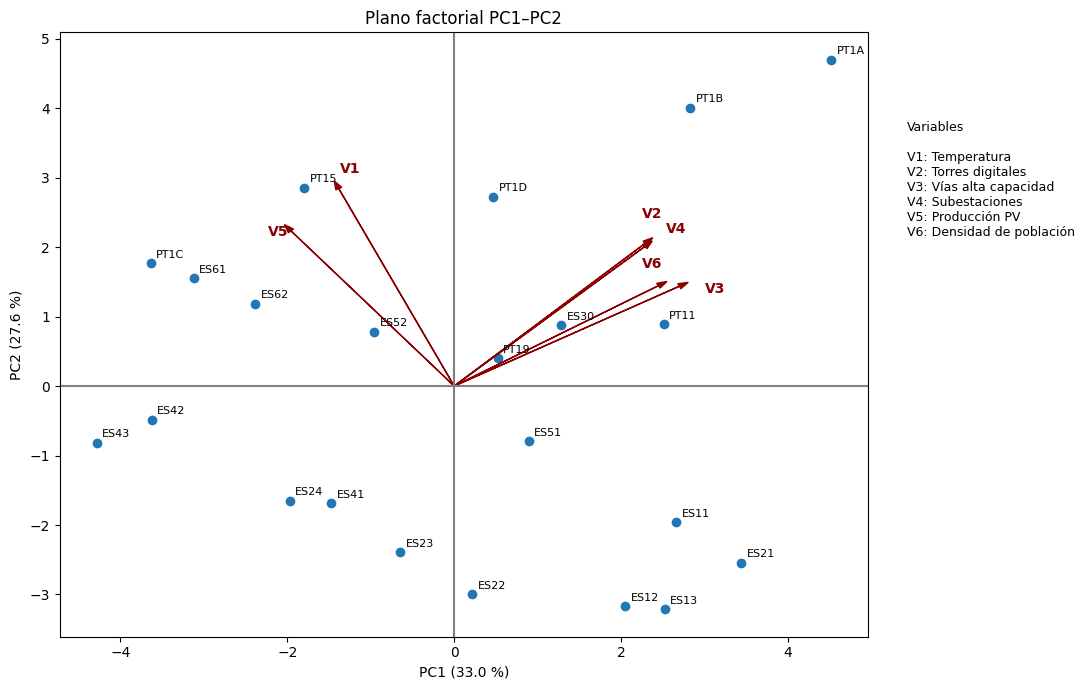

In [22]:
# Plano factorial PC1-PC2
fig, ax = plt.subplots(figsize=(12, 7))

# Territorios.
ax.scatter(
    scores_territorios["PC1"],
    scores_territorios["PC2"],
)
for fila in scores_territorios.itertuples():
    ax.annotate(
        fila.codigo_geo,
        (fila.PC1, fila.PC2),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

# Seis variables principales.
magnitud = np.hypot(
    loadings["PC1"],
    loadings["PC2"],
)
variables_biplot = magnitud.nlargest(6).index
nombres_cortos = {
    "temperatura_media_2m_c": "Temperatura",
    "digital_torres_mastiles_1000km2":
        "Torres digitales",
    "logistica_road_alta_capacidad_km_por_1000km2":
        "Vías alta capacidad",
    "electrica_densidad_subestaciones_1000km2":
        "Subestaciones",
    "pvgis_produccion_anual_kwh_kwp":
        "Producción PV",
    "precipitation_daily_mean_mm_2024_2025":
        "Precipitación",
    "densidad_poblacion":
        "Densidad de población",
}
desplazamientos = {
    1: (4, 6),
    2: (-8, 14),
    3: (12, -8),
    4: (10, 6),
    5: (-12, -8),
    6: (-18, 10),
}
escala = 3.5
for numero, variable in enumerate(
    variables_biplot,
    start=1,
):
    x = loadings.loc[variable, "PC1"] * escala
    y = loadings.loc[variable, "PC2"] * escala
    ax.arrow(
        0, 0, x, y,
        color="darkred",
        head_width=0.08,
        length_includes_head=True,
    )
    ax.annotate(
        f"V{numero}",
        (x, y),
        xytext=desplazamientos[numero],
        textcoords="offset points",
        color="darkred",
        fontweight="bold",
    )

# Leyenda de las variables.
leyenda = "\n".join(
    f"V{i}: {nombres_cortos.get(variable, variable)}"
    for i, variable in enumerate(
        variables_biplot,
        start=1,
    )
)
fig.text(
    0.76,
    0.82,
    "Variables\n\n" + leyenda,
    va="top",
    fontsize=9,
)

# Formato final.
ax.axhline(0, color="gray")
ax.axvline(0, color="gray")
ax.set(
    xlabel=f"PC1 ({varianza_final_pct[0]:.1f} %)",
    ylabel=f"PC2 ({varianza_final_pct[1]:.1f} %)",
    title="Plano factorial PC1–PC2",
)
fig.tight_layout(rect=(0, 0, 0.74, 1))
fig.savefig(
    OUTPUT_DIR / "biplot_pc1_pc2.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)


### Interpretación del plano factorial

Grande Lisboa y Península de Setúbal se sitúan en la zona positiva de PC1 y PC2, asociada principalmente con infraestructura digital, eléctrica y logística.

Algarve aparece en la zona negativa de PC1 y positiva de PC2, próxima a las direcciones de temperatura y producción fotovoltaica.

Las flechas que apuntan en direcciones similares representan variables relacionadas positivamente. Las direcciones opuestas indican relaciones negativas.

El gráfico representa únicamente PC1 y PC2, que explican conjuntamente el **60,59 %** de la varianza. Por tanto, PC3 también debe tenerse en cuenta en la interpretación completa.

## Relación con Isolation Forest

Isolation Forest detecta territorios con perfiles multivariantes singulares, mientras que el PCA resume las principales dimensiones de variación.

Comparamos ambos resultados para comprobar si los territorios señalados en el Notebook 13 también ocupan posiciones extremas en PC1, PC2 o PC3.

No esperamos una coincidencia completa, ya que ambos métodos analizan aspectos diferentes de los datos.

In [23]:
# Carga de Isolation Forest
isolation_resumen = pd.read_csv(
    ISOLATION_PATH
)

columnas_if = [
    "codigo_geo",
    "score_anomalia",
    "singular",
    "veces_singular",
    "frecuencia",
    "n_umbrales",
]

if (
    len(isolation_resumen) != 22
    or not isolation_resumen["codigo_geo"].is_unique
    or not set(columnas_if).issubset(
        isolation_resumen.columns
    )
):
    raise ValueError(
        "Los resultados de Isolation Forest necesitan revisión."
    )

print(
    "Territorios:", len(isolation_resumen),
    "| Columnas:", len(isolation_resumen.columns),
)
display(
    isolation_resumen[columnas_if]
    .head()
    .round(3)
)


Territorios: 22 | Columnas: 12


,codigo_geo,score_anomalia,singular,veces_singular,frecuencia,n_umbrales
0,PT1A,0.041,True,5,1.0,3
1,PT1B,0.002,True,4,0.8,3
2,ES30,0.000,True,3,0.6,2
3,PT15,-0.001,False,3,0.6,1
4,PT1C,-0.003,False,0,0.0,0


### Integración de PCA e Isolation Forest

Unimos las puntuaciones de PC1, PC2 y PC3 con los resultados de Isolation Forest mediante `codigo_geo`.

La tabla permitirá comparar la posición de cada territorio con su nivel de singularidad. Los resultados de Isolation Forest se utilizan únicamente para interpretar el PCA y no como variables del modelo.

In [24]:
# Integración PCA e Isolation Forest
columnas_iso = [
    "codigo_geo",
    "score_anomalia",
    "singular",
    "veces_singular",
    "frecuencia",
    "cont_05",
    "cont_10",
    "cont_15",
    "n_umbrales",
    "ranking_singularidad",
]

pca_iso = scores_territorios.merge(
    isolation_resumen[columnas_iso],
    on="codigo_geo",
    how="left",
    validate="one_to_one",
)
if (
    len(pca_iso) != 22
    or not pca_iso["codigo_geo"].is_unique
    or pca_iso[columnas_iso[1:]].isna().any().any()
):
    raise ValueError(
        "La integración PCA–Isolation Forest necesita revisión."
    )
pca_iso = pca_iso.sort_values(
    "ranking_singularidad"
).reset_index(drop=True)
pca_iso.to_csv(
    OUTPUT_DIR / "integracion_pca_isolation_forest.csv",
    index=False,
)
print(
    "Territorios:", len(pca_iso),
    "| Singulares:",
    int(pca_iso["singular"].sum()),
)
display(pca_iso.round(3))


Territorios: 22 | Singulares: 3


,codigo_geo,nombre_territorio,pais,PC1,PC2,PC3,score_anomalia,singular,veces_singular,frecuencia,cont_05,cont_10,cont_15,n_umbrales,ranking_singularidad
0,PT1A,Grande Lisboa,Portugal,4.518,4.695,0.982,0.041,True,5,1.0,True,True,True,3,1
1,PT1B,Península de Setúbal,Portugal,2.823,4.001,0.433,0.002,True,4,0.8,True,True,True,3,2
2,ES30,Comunidad de Madrid,España,1.285,0.875,3.512,0.000,True,3,0.6,False,True,True,2,3
3,PT15,Algarve,Portugal,-1.801,2.853,-0.676,-0.001,False,3,0.6,False,False,True,1,4
4,PT1C,Alentejo,Portugal,-3.635,1.767,-1.799,-0.003,False,0,0.0,False,False,False,0,5
5,ES43,Extremadura,España,-4.286,-0.814,0.083,-0.003,False,0,0.0,False,False,False,0,6
6,ES61,Andalucía,España,-3.123,1.550,0.801,-0.011,False,0,0.0,False,False,False,0,7
7,ES42,Castilla-La Mancha,España,-3.623,-0.486,-0.562,-0.026,False,0,0.0,False,False,False,0,8
8,PT11,Norte,Portugal,2.512,0.889,-1.662,-0.026,False,0,0.0,False,False,False,0,9
9,ES62,Región de Murcia,España,-2.384,1.181,2.351,-0.027,False,0,0.0,False,False,False,0,10


### Interpretación conjunta

PCA e Isolation Forest ofrecen resultados coherentes, aunque analizan aspectos diferentes.

**Grande Lisboa**, primera en el ranking de singularidad, presenta las puntuaciones más elevadas en PC1 y PC2.

**Península de Setúbal**, segunda en el ranking, también destaca por valores altos en PC1 y PC2.

**Comunidad de Madrid**, tercera, alcanza la puntuación más elevada en PC3.

**Algarve** ocupa la cuarta posición del ranking, pero no se clasifica como singular en el modelo base. Su resultado es menos estable y destaca principalmente por su posición positiva en PC2.

Otros territorios también ocupan posiciones extremas en algún componente sin ser clasificados como singulares. Esto ocurre porque el PCA representa dimensiones de variación, mientras que Isolation Forest detecta combinaciones globales poco habituales.

Mantenemos los **22 territorios** y utilizamos Isolation Forest únicamente como apoyo para interpretar el PCA.

## Sensibilidad frente a territorios singulares

Repetimos temporalmente el PCA sin los territorios que presentan una frecuencia elevada de singularidad en Isolation Forest.

Mantenemos las mismas **19 variables**, el mismo preprocesamiento y los tres componentes. El objetivo es comprobar si la estructura del PCA depende demasiado de unos pocos territorios.

Esta prueba no sustituye al PCA principal ni implica eliminar territorios. Comparamos la varianza explicada y las cargas, teniendo en cuenta que el signo de los componentes puede invertirse.

In [25]:
# Sensibilidad sin singularidades estables
codigos_singulares = isolation_resumen.loc[
    isolation_resumen["frecuencia"] >= 0.75,
    "codigo_geo",
].tolist()

mascara_reducida = ~df["codigo_geo"].isin(
    codigos_singulares
)
X_reducida = X_pca.loc[
    mascara_reducida
].copy()

if (
    len(codigos_singulares) != 2
    or X_reducida.shape != (20, 19)
):
    raise ValueError(
        "La matriz de sensibilidad necesita revisión."
    )

# PCA temporal con los mismos tres componentes.
pca_reducida = PCA(
    n_components=N_COMPONENTES
)
scores_reducidos = pd.DataFrame(
    pca_reducida.fit_transform(X_reducida),
    columns=nombres_pc,
    index=X_reducida.index,
)
loadings_reducida = pd.DataFrame({
    pc: X_reducida.corrwith(
        scores_reducidos[pc]
    )
    for pc in nombres_pc
})

# Comparación con el PCA principal.
registros_sensibilidad = []
for posicion, pc in enumerate(nombres_pc):
    correlacion = loadings[pc].corr(
        loadings_reducida[pc]
    )

    registros_sensibilidad.append({
        "componente": pc,
        "correlacion_abs_cargas": abs(correlacion),
        "varianza_completa_pct":
            varianza_final_pct[posicion],
        "varianza_sin_singulares_pct":
            pca_reducida.explained_variance_ratio_[
                posicion
            ] * 100,
    })
comparacion_cargas = pd.DataFrame(
    registros_sensibilidad
)
comparacion_cargas.to_csv(
    OUTPUT_DIR / "sensibilidad_pca_sin_singulares.csv",
    index=False,
)
print(
    "Territorios excluidos:",
    codigos_singulares,
)
print(
    "Matriz reducida:", X_reducida.shape,
    "| Varianza completa:",
    f"{varianza_final_pct.sum():.2f} %",
    "| Sin singulares:",
    f"{pca_reducida.explained_variance_ratio_.sum() * 100:.2f} %",
)
display(comparacion_cargas.round(3))


Territorios excluidos: ['PT1A', 'PT1B']
Matriz reducida: (20, 19) | Varianza completa: 74.54 % | Sin singulares: 72.76 %


,componente,correlacion_abs_cargas,varianza_completa_pct,varianza_sin_singulares_pct
0,PC1,0.887,32.994,38.683
1,PC2,0.571,27.594,19.393
2,PC3,0.619,13.947,14.683


### Interpretación de la sensibilidad

Retiramos temporalmente Grande Lisboa y Península de Setúbal, los dos territorios con una frecuencia de singularidad igual o superior a `0,75`.

La varianza acumulada de los tres componentes cambia poco: pasa del **74,54 %** al **72,76 %**, aunque su distribución entre componentes se modifica.

PC1 mantiene una estructura bastante estable, con una correlación absoluta de cargas de `0,887`. PC2 y PC3 presentan una estabilidad más moderada, con valores de `0,571` y `0,619`, por lo que son sensibles a la retirada de estos territorios.

La capacidad global de síntesis del PCA se mantiene, pero la interpretación de los componentes secundarios debe realizarse con cautela.

Mantenemos los **22 territorios** en el PCA principal, ya que la singularidad detectada por Isolation Forest se usa como criterio de contraste y no como motivo automático de exclusión.

## Síntesis de los componentes

Creamos una tabla resumen para cada componente con:

- la varianza explicada y acumulada;
- las variables con cargas `|carga| ≥ 0,40`;
- las tres familias principales;
- los territorios con puntuaciones extremas.

Esta tabla facilitará la interpretación del PCA y su incorporación a la memoria.

In [26]:
# Síntesis de los componentes
sintesis = []
familias = contrib_familias.set_index("familia")
varianza_acumulada = np.cumsum(varianza_final_pct)

for i, pc in enumerate(nombres_pc):
    cargas = loadings.loc[
        loadings[pc].abs() >= LOADING_THRESHOLD,
        pc,
    ].sort_values(
        key=np.abs,
        ascending=False,
    )
    familias_top = familias[pc].nlargest(3)
    positivos = scores_territorios.nlargest(
        3, pc
    )["nombre_territorio"]
    negativos = scores_territorios.nsmallest(
        3, pc
    )["nombre_territorio"]
    sintesis.append({
        "componente": pc,
        "varianza_pct": varianza_final_pct[i],
        "varianza_acumulada_pct":
            varianza_acumulada[i],
        "variables_principales": " | ".join(
            f"{variable} ({carga:+.2f})"
            for variable, carga in cargas.items()
        ),
        "familias_principales": " | ".join(
            f"{familia} ({valor:.1f} %)"
            for familia, valor
            in familias_top.items()
        ),
        "territorios_positivos":
            " | ".join(positivos),
        "territorios_negativos":
            " | ".join(negativos),
    })

sintesis_componentes = pd.DataFrame(sintesis)
sintesis_componentes.to_csv(
    OUTPUT_DIR / "sintesis_componentes_memoria.csv",
    index=False,
)
print("Componentes:", len(sintesis_componentes))
display(sintesis_componentes.round(3))


Componentes: 3


,componente,varianza_pct,varianza_acumulada_pct,variables_principales,familias_principales,territorios_positivos,territorios_negativos
0,PC1,32.994,32.994,logistica_places_n_por_1000km2 (+0.80) | logis...,Logística (20.5 %) | PVGIS (18.0 %) | Eléctric...,Grande Lisboa | País Vasco | Península de Setúbal,Extremadura | Alentejo | Castilla-La Mancha
1,PC2,27.594,60.588,temperatura_media_2m_c (+0.84) | punto_rocio_m...,Climática (28.3 %) | Digital (15.2 %) | PVGIS ...,Grande Lisboa | Península de Setúbal | Algarve,Cantabria | Principado de Asturias | Comunidad...
2,PC3,13.947,74.536,ambiental_penalizacion_media_0_1 (+0.71) | niv...,Ambiental (30.0 %) | Socioeconómica (20.9 %) |...,Comunidad de Madrid | Región de Murcia | Comun...,Oeste e Vale do Tejo | Centro (PT) | Galicia


### Lectura final de los componentes

PC1 representa un eje mixto relacionado con las infraestructuras territoriales, la logística y las condiciones fotovoltaicas.

PC2 recoge sobre todo las diferencias climáticas, solares y digitales.

PC3 está relacionado principalmente con las condiciones ambientales y socioeconómicas.

Estas denominaciones son interpretativas y resumen las variables y familias con mayor peso en cada componente.

## Salida para Power BI

Transformamos las puntuaciones del PCA a formato longitudinal, con una fila por territorio y componente.

La tabla facilitará su uso en Power BI y en el modelo semántico. La matriz ancha se mantiene como entrada para el clustering.

In [27]:
# Salida longitudinal para Power BI
scores_long = scores_territorios.melt(
    id_vars=[
        "codigo_geo",
        "nombre_territorio",
        "pais",
    ],
    value_vars=nombres_pc,
    var_name="componente",
    value_name="puntuacion_pca",
)
scores_long = scores_long.merge(
    resumen_pca_final,
    on="componente",
    how="left",
    validate="many_to_one",
)
if (
    scores_long.shape != (66, 7)
    or scores_long["codigo_geo"].nunique() != 22
    or scores_long["componente"].nunique() != 3
    or scores_long.isna().any().any()
):
    raise ValueError(
        "La salida para Power BI necesita revisión."
    )
scores_long.to_csv(
    OUTPUT_DIR / "pca_territorios_formato_powerbi.csv",
    index=False,
)
print(
    "Filas:", len(scores_long),
    "| Territorios:",
    scores_long["codigo_geo"].nunique(),
    "| Componentes:",
    scores_long["componente"].nunique(),
)
display(scores_long.head(12).round(3))


Filas: 66 | Territorios: 22 | Componentes: 3


,codigo_geo,nombre_territorio,pais,componente,puntuacion_pca,varianza_explicada_pct,varianza_acumulada_pct
0,ES11,Galicia,España,PC1,2.659,32.994,32.994
1,ES12,Principado de Asturias,España,PC1,2.050,32.994,32.994
2,ES13,Cantabria,España,PC1,2.523,32.994,32.994
3,ES21,País Vasco,España,PC1,3.439,32.994,32.994
4,ES22,Comunidad Foral de Navarra,España,PC1,0.212,32.994,32.994
5,ES23,La Rioja,España,PC1,-0.645,32.994,32.994
6,ES24,Aragón,España,PC1,-1.971,32.994,32.994
7,ES30,Comunidad de Madrid,España,PC1,1.285,32.994,32.994
8,ES41,Castilla y León,España,PC1,-1.472,32.994,32.994
9,ES42,Castilla-La Mancha,España,PC1,-3.623,32.994,32.994


## Conclusiones metodológicas

En este notebook hemos aplicado PCA sobre la matriz estandarizada del Notebook 12, formada inicialmente por **22 territorios y 21 variables**.

El diagnóstico inicial mostró un KMO bajo (`0,319`), aunque la prueba de Bartlett confirmó que existían correlaciones suficientes para continuar el análisis. Para mejorar la adecuación retiramos `tasa_desempleo` y `poblacion_edad_laboral` únicamente de la matriz específica del PCA. Mantenemos ambas variables en la matriz general del proyecto.

La matriz definitiva del PCA quedó formada por **22 territorios y 19 variables**, con un KMO de `0,560`.

Para seleccionar los componentes combinamos varios criterios:

- Kaiser propuso cuatro componentes;
- el análisis paralelo recomendó tres;
- el gráfico de sedimentación mostró un cambio claro después de PC3;
- los tres primeros componentes explicaron el **74,54 %** de la varianza.

Por estos motivos conservamos **tres componentes**:

- **PC1:** infraestructuras territoriales, logística y condiciones fotovoltaicas;
- **PC2:** dimensión climática, solar y digital;
- **PC3:** dimensión ambiental y socioeconómica.

La comparación con Isolation Forest mostró resultados coherentes. Grande Lisboa y Península de Setúbal presentan posiciones elevadas en PC1 y PC2, mientras que Comunidad de Madrid destaca principalmente en PC3.

La prueba de sensibilidad mostró que, al retirar temporalmente Grande Lisboa y Península de Setúbal, la varianza acumulada de los tres componentes cambia poco, del **74,54 %** al **72,76 %**. PC1 mantiene una estructura bastante estable (`0,887`), mientras que PC2 (`0,571`) y PC3 (`0,619`) son más sensibles a esta retirada y deben interpretarse con cautela.

Mantenemos los **22 territorios** en el análisis principal. Usamos la singularidad detectada mediante Isolation Forest como contraste y no como criterio automático de exclusión.

El PCA no genera automáticamente pesos para el IIT-CPD ni representa un ranking de idoneidad. Sus tres puntuaciones se utilizarán como entrada para el clustering posterior.

Debido al reducido número de territorios, interpretamos este PCA como un análisis exploratorio. Las salidas quedan preparadas para los siguientes notebooks y para su futura integración en Power BI y en el modelo semántico.

## Cierre y empaquetado de resultados

Para cerrar el Notebook 14 comprobamos que se hayan generado correctamente las principales tablas y figuras del PCA.

Después reunimos todas las salidas en un único archivo ZIP para conservar la trazabilidad y reutilizarlas en los siguientes notebooks, la memoria y, más adelante, en Power BI.

In [28]:
# Cierre y ZIP final
from zipfile import ZipFile, ZIP_DEFLATED

tablas = [
    "matriz_correlacion_pearson.csv",
    "matriz_correlacion_spearman.csv",
    "pares_correlacion_ordenados.csv",
    "resumen_componentes_completo.csv",
    "resumen_pca_final.csv",
    "analisis_paralelo.csv",
    "cargas_pca.csv",
    "contribuciones_variables_componentes.csv",
    "comunalidades_variables.csv",
    "variables_principales_por_componente.csv",
    "contribucion_familias_componentes.csv",
    "puntuaciones_territoriales_pca.csv",
    "territorios_extremos_por_componente.csv",
    "integracion_pca_isolation_forest.csv",
    "sensibilidad_pca_sin_singulares.csv",
    "sintesis_componentes_memoria.csv",
    "pca_territorios_formato_powerbi.csv",
]
figuras = [
    "matriz_correlacion_spearman.png",
    "scree_plot_analisis_paralelo.png",
    "varianza_explicada_pca.png",
    "contribucion_familias_componentes.png",
    "biplot_pc1_pc2.png",
]
archivos_zip = tablas + figuras
faltantes = [
    nombre
    for nombre in archivos_zip
    if not (OUTPUT_DIR / nombre).exists()
]
if faltantes:
    raise FileNotFoundError(
        f"Faltan archivos: {faltantes}"
    )
ZIP_PATH = Path(
    "/kaggle/working/NB14_PCA_SALIDAS_COMPLETAS.zip"
)
with ZipFile(
    ZIP_PATH,
    "w",
    compression=ZIP_DEFLATED,
) as zipf:
    for nombre in archivos_zip:
        zipf.write(
            OUTPUT_DIR / nombre,
            arcname=nombre,
        )
print(
    "Tablas:", len(tablas),
    "| Figuras:", len(figuras),
    "| Archivos ZIP:", len(archivos_zip),
)
print("ZIP:", ZIP_PATH)


Tablas: 17 | Figuras: 5 | Archivos ZIP: 22
ZIP: /kaggle/working/NB14_PCA_SALIDAS_COMPLETAS.zip
